# ChurnSense — Model Evaluation & Selection

## Objective

The objective of this notebook is to evaluate and improve the churn prediction models.

We will:

- Compare Precision and Recall
- Plot ROC curves
- Create confusion matrices
- Tune the best-performing model
- Evaluate feature importance using SHAP
- Save the final churn prediction model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from sklearn.pipeline import Pipeline

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

from src.preprocessing import load_data, prepare_data, create_preprocessor

df = pd.read_csv(DATA_PATH)
X, y, numeric_features, categorical_features = prepare_data(df)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5634, 20)
Testing shape: (1409, 20)


In [5]:
preprocessor = create_preprocessor(
    numeric_features,
    categorical_features
)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [7]:
pipelines = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", models["Logistic Regression"])
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", models["Decision Tree"])
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", models["Random Forest"])
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", models["Gradient Boosting"])
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", models["XGBoost"])
    ])
}

In [8]:
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name} trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully
XGBoost trained successfully


In [9]:
for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    ))

Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.84      0.87      0.85      1035
       Churn       0.59      0.53      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.78      0.77      1409

Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.86      1035
       Churn       0.65      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78   

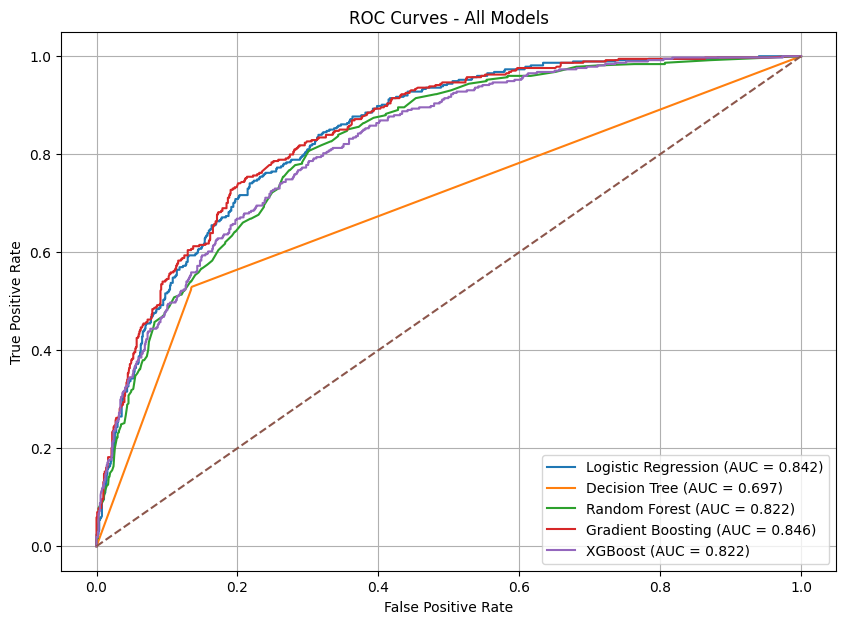

In [10]:
plt.figure(figsize=(10, 7))

for name, pipeline in pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend()
plt.grid()

plt.show()

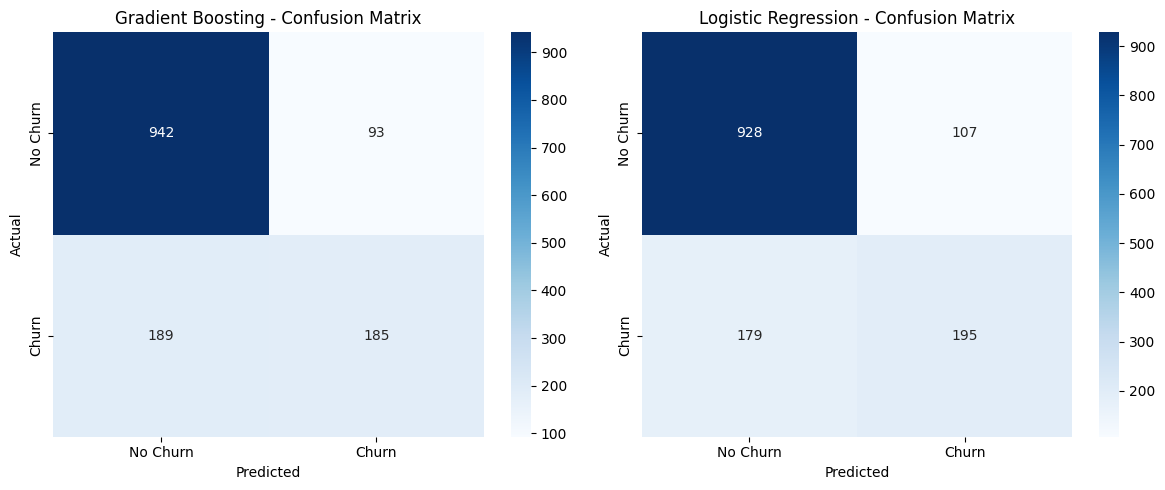

In [11]:
top_models = {
    "Gradient Boosting": pipelines["Gradient Boosting"],
    "Logistic Regression": pipelines["Logistic Regression"]
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, pipeline) in zip(axes, top_models.items()):
    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
        ax=ax
    )

    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [12]:
param_dist = {
    "model__n_estimators": [100, 150, 200, 250],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.15],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

gb_pipeline = pipelines["Gradient Boosting"]

random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV AUC:")
print(random_search.best_score_)

Best Parameters:
{'model__n_estimators': 250, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.05}

Best CV AUC:
0.8492790283953597


In [13]:
best_model = random_search.best_estimator_

y_test_prob = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_test_prob)

print("Tuned Gradient Boosting Test AUC:", test_auc)

Tuned Gradient Boosting Test AUC: 0.8452840424707433


In [14]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.49.1


In [15]:
explainer = shap.Explainer(
    best_model.named_steps["model"],
    best_model.named_steps["preprocessor"].transform(X_train)
)

X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

shap_values = explainer(X_test_transformed)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    show=True
)

ValueError: setting an array element with a sequence.

In [19]:
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix to dense
X_train_dense = X_train_transformed.toarray()
X_test_dense = X_test_transformed.toarray()

print("Train shape:", X_train_dense.shape)
print("Test shape:", X_test_dense.shape)

Train shape: (5634, 5324)
Test shape: (1409, 5324)


In [16]:
print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotalCharges dtype:")
print(X["TotalCharges"].dtype)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'tenure_group']

TotalCharges dtype:
object


In [17]:
X["TotalCharges"] = pd.to_numeric(
    X["TotalCharges"],
    errors="coerce"
)

X["TotalCharges"] = X["TotalCharges"].fillna(0)

# Recreate feature lists
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
print("X shape:", X.shape)

print("\nColumns:")
print(X.columns.tolist())

print("\nTotalCharges dtype:")
print(X["TotalCharges"].dtype)

print("\nTenure group present:")
print("tenure_group" in X.columns)

X shape: (7043, 20)

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group']

TotalCharges dtype:
float64

Tenure group present:
True


In [19]:
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

test_preprocessor = create_preprocessor(
    numeric_features,
    categorical_features
)

test_output = test_preprocessor.fit_transform(X_train_fixed)

print("\nProcessed shape:", test_output.shape)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numeric features: 4
Number of categorical features: 15


NameError: name 'X_train_fixed' is not defined

In [22]:
X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

test_preprocessor = create_preprocessor(
    numeric_features,
    categorical_features
)

test_output = test_preprocessor.fit_transform(X_train_fixed)

print("Train shape:", X_train_fixed.shape)
print("Processed shape:", test_output.shape)

Train shape: (5634, 20)
Processed shape: (5634, 45)


In [20]:
X_train_dense = test_output
X_test_dense = test_preprocessor.transform(X_test_fixed)

print("Train shape:", X_train_dense.shape)
print("Test shape:", X_test_dense.shape)

NameError: name 'test_output' is not defined

In [21]:
# Recreate train/test split
X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Recreate preprocessor
test_preprocessor = create_preprocessor(
    numeric_features,
    categorical_features
)

# Fit preprocessing on training data
X_train_transformed = test_preprocessor.fit_transform(X_train_fixed)

# Transform test data
X_test_transformed = test_preprocessor.transform(X_test_fixed)

print("Train shape:", X_train_transformed.shape)
print("Test shape:", X_test_transformed.shape)

Train shape: (5634, 45)
Test shape: (1409, 45)


In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

tuned_gb = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42
)

tuned_pipeline = Pipeline([
    ("preprocessor", test_preprocessor),
    ("model", tuned_gb)
])

tuned_pipeline.fit(X_train_fixed, y_train_fixed)

print("Tuned Gradient Boosting trained successfully!")

Tuned Gradient Boosting trained successfully!


In [23]:
# Use a small sample for SHAP
X_shap = X_test_transformed[:200]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (200, 45)


In [24]:
model = tuned_pipeline.named_steps["model"]

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated successfully!")
print("SHAP shape:", shap_values.shape)

SHAP values calculated successfully!
SHAP shape: (200, 45)


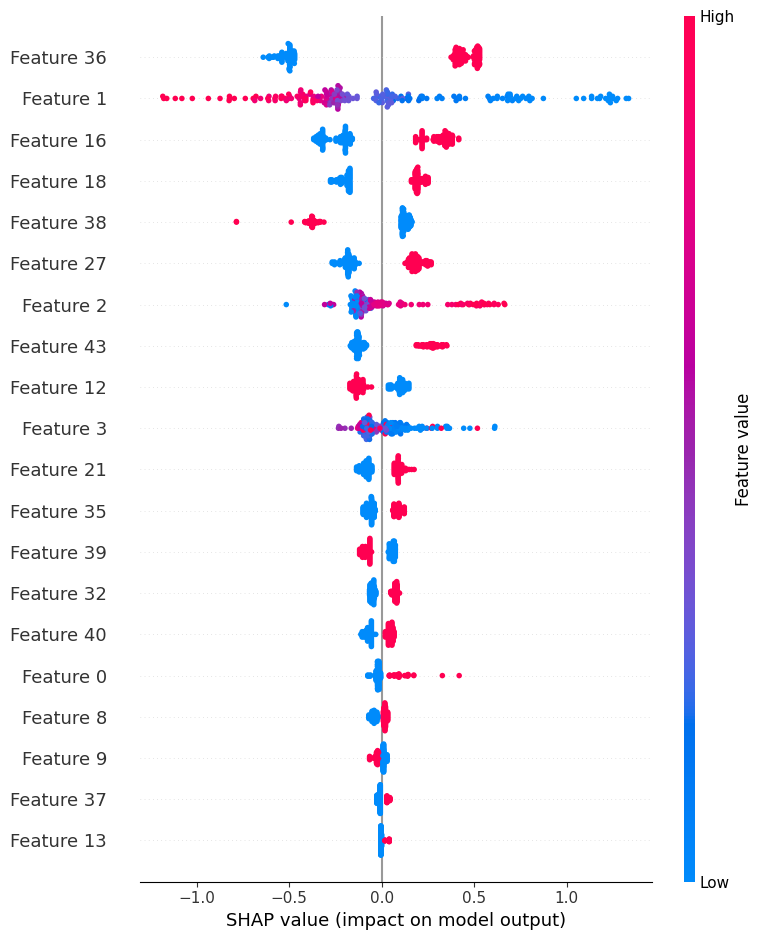

In [25]:
shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

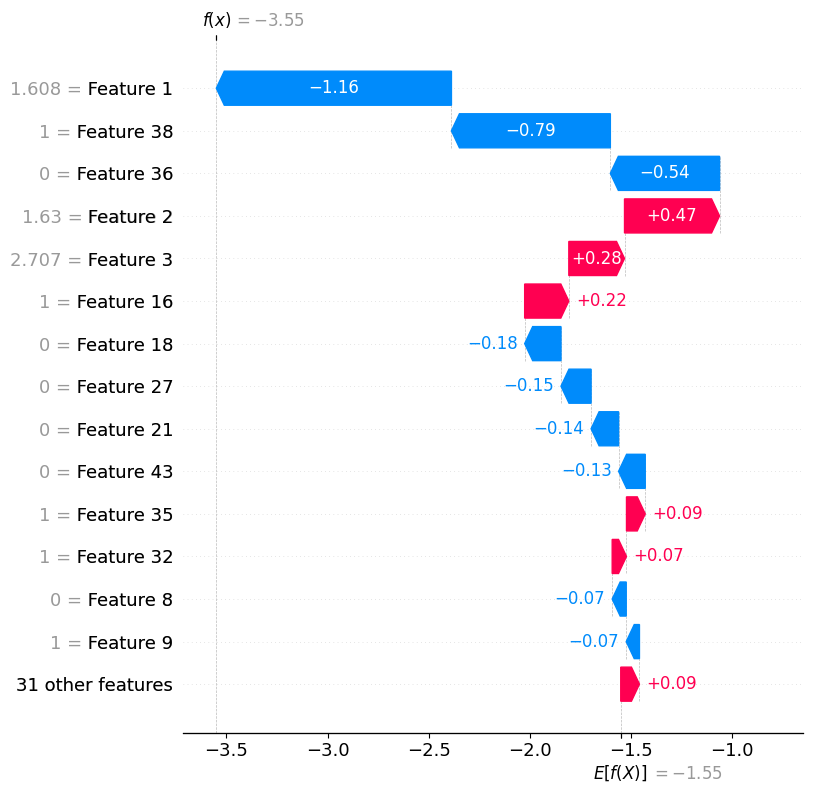

In [26]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_shap[0]
    ),
    max_display=15
)

In [27]:
from sklearn.metrics import roc_auc_score

y_test_prob = tuned_pipeline.predict_proba(X_test_fixed)[:, 1]

final_test_auc = roc_auc_score(
    y_test_fixed,
    y_test_prob
)

print("Final Tuned Model Test AUC:", final_test_auc)

Final Tuned Model Test AUC: 0.845271125578031


In [28]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_path = "../models/churn_model_v1.pkl"

joblib.dump(
    tuned_pipeline,
    model_path
)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ../models/churn_model_v1.pkl


# ChurnSense — Model Card

## Model Overview

Model: Gradient Boosting Classifier

Task: Customer Churn Prediction

Dataset: IBM Telco Customer Churn Dataset

Target: Churn

## Model Development

The model uses a preprocessing pipeline with:

- StandardScaler for numerical features
- OneHotEncoder for categorical features
- Tenure group feature engineering

The final model was tuned using RandomizedSearchCV.

## Best Hyperparameters

- n_estimators: 250
- learning_rate: 0.05
- max_depth: 2
- min_samples_split: 10
- min_samples_leaf: 2

## Performance

Cross-validation AUC: 0.8493

Test AUC: 0.8453

## Model Interpretation

SHAP was used to understand feature contributions to churn predictions.

A SHAP summary plot and waterfall plot were generated during evaluation.

## Intended Use

The model is intended to support customer churn analysis and identify customers who may have a higher probability of churning.

## Limitations

Model performance depends on the quality and characteristics of the training data. Predictions should be treated as decision-support information rather than guaranteed outcomes.

## Model Artifact

Saved model:

`models/churn_model_v1.pkl`